# 📔 **Resolución**
Una vez que la nota sea entregada, encontrarás la resolución en este link de notion:

https://www.notion.so/R-DT-and-ensemble-models-1eb05737435780bf924fd27f0fc8c06c?source=copy_link

Recuerda que existen varias formar de solucionar las actividades propuestas en los laboratorios. Toma la resolución entregada como referencia. En caso de que el link de resolución no esté público, solicita acceso en el mismo link de notion.|

# Decision Trees, Random Forest and XGBoost models

Let's import the libraries you will use.

In [4]:
#!wget https://raw.githubusercontent.com/mtgca/datasets_public/main/deeplearning.mplstyle
#!wget https://raw.githubusercontent.com/mtgca/datasets_public/main/heart.csv

import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/mtgca/datasets_public/main/deeplearning.mplstyle",
    "deeplearning.mplstyle"
)

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/mtgca/datasets_public/main/heart.csv",
    "heart.csv"
)


('heart.csv', <http.client.HTTPMessage at 0x2624ceb0>)

In [5]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
!pip install xgboost --quiet
import xgboost
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')

RANDOM_STATE = 55 ## You will pass it to every sklearn call so we ensure reproducibility

# 1. Loading the Dataset

From [Kaggle](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

Context
Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths worldwide. Heart failure is a common event caused by CVDs and this dataset contains 11 features that can be used to predict a possible heart disease.

People with cardiovascular disease or who are at high cardiovascular risk need early detection and management wherein a machine learning model can be of great help.

You will develop models to predict how likely a particular person is in developint cardiovascular disease, given all the information below.

#### Attribute Information
- Age: age of the patient [years]
- Sex: sex of the patient [M: Male, F: Female]
- ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
- RestingBP: resting blood pressure [mm Hg]
- Cholesterol: serum cholesterol [mm/dl]
- FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
- RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
- MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
- ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
- Oldpeak: oldpeak = ST [Numeric value measured in depression]
- ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
- HeartDisease: output class [1: heart disease, 0: Normal]

Let's now load the dataset. As you can see above, the variables:

- Sex
- ChestPainType
- RestingECG
- ExerciseAngina
- ST_Slope

Are *categorical*, so you must one-hot encode them.

In [6]:
# Load the dataset using pandas
df = pd.read_csv("heart.csv")

In [7]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


You must perform some data engineering before working with the models. There are 5 categorical features, so you will use Pandas to one-hot encode them.

## 2. One-hot encoding using Pandas

First you will remove the binary variables, because one-hot encoding them would do nothing to them. To achieve this you will just count how many different values there are in each categorical variable and consider only the variables with 3 or more values.

In [8]:
cat_variables = ['Sex',
'ChestPainType',
'RestingECG',
'ExerciseAngina',
'ST_Slope'
]

As a reminder, one-hot encoding aims to transform a categorical variable with `n` outputs into `n` binary variables.

Pandas has a built-in method to one-hot encode variables, it is the function `pd.get_dummies`. There are several arguments to this function, but here you will use only a few. They are:

 - data: DataFrame to be used
 - prefix: A list with prefixes, so you know which value you are dealing with
 - columns: the list of columns that will be one-hot encoded. 'prefix' and 'columns' must have the same length.

For more information, you can always type `help(pd.get_dummies)` to read the function's full documentation.

In [9]:
# This will replace the columns with the one-hot encoded ones and keep the columns outside 'columns' argument as it is.
df = pd.get_dummies(data = df,
                         prefix = cat_variables,
                         columns = cat_variables)

In [10]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


You now will define the final set of variables that will be used by the models you will build in this lab.

In [11]:
var = [x for x in df.columns if x not in 'HeartDisease'] ## Removing our target variable

Note how the number of variables has changed. You started with 11 variables now you have:

In [12]:
print(len(var))

20


# 3. Splitting the Dataset

In this section, you will split our dataset into train and test datasets. You will use the function `train_test_split` from Scikit-learn. Let's just check its arguments.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(df[var], df['HeartDisease'], train_size = 0.8, random_state = RANDOM_STATE)

# We will keep the shuffle = True since our dataset has not any time dependency.

In [14]:
print(f'train samples: {len(X_train)}\ntest samples: {len(X_test)}')
print(f'target proportion: {sum(y_train)/len(y_train):.4f}')

train samples: 734
test samples: 184
target proportion: 0.5518


# 4. Building the Models

## 4.1 Decision Tree

In this section, let's work with the Decision Tree you previously learned, but now using the [Scikit-learn implementation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).

There are several hyperparameters in the Decision Tree object from Scikit-learn. You will use only some of them and also you will not perform feature selection nor hyperparameter tuning in this lab (but you are encouraged to do so and compare the results :-) )


The hyperparameters you will use and investigate here is:

 - min_samples_split: The minimum number of samples required to split an internal node. This may prevent overfitting.
 - max_depth: The maximum depth of the tree. This may prevent overfitting.

In [15]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700] ## If the number is an integer, then it is the actual quantity of samples,
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64, None] # None means that there is no depth limit.

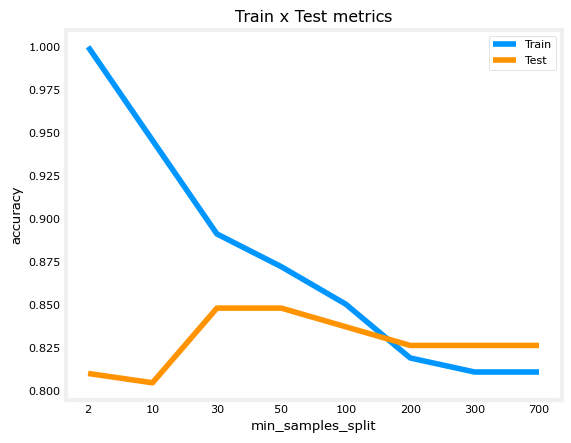

In [16]:
accuracy_list_train = []
accuracy_list_test = []
for min_samples_split in min_samples_split_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = DecisionTreeClassifier(min_samples_split = min_samples_split,
                                   random_state = RANDOM_STATE).fit(X_train,y_train)
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

Note how increasing the the number of `min_samples_split` decreases the overfit.

Let's do the same experiment with `max_depth`.

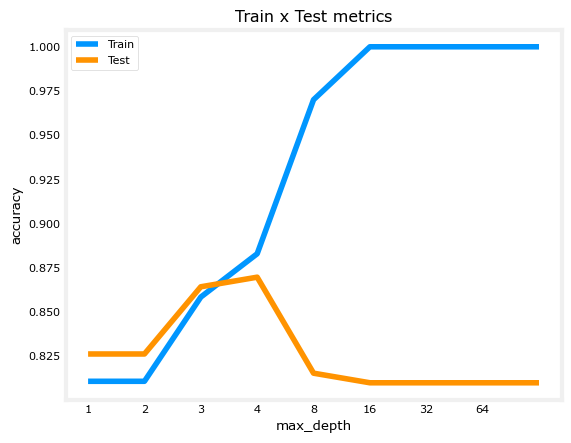

In [17]:
accuracy_list_train = []
accuracy_list_test = []
for max_depth in max_depth_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = DecisionTreeClassifier(max_depth = max_depth,
                                   random_state = RANDOM_STATE).fit(X_train,y_train)
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

The test accuracy reaches the highest at tree_depth=3. When the allowed depth is smaller, the tree cannot make enough splits to distinguish positives from negatives (having the underfit problem), but when the allowed depth is too high ( >= 5), the tree becomes too specialized to the training set and thus losing accuracy to the test dataset (having the overfit problem). Our final tree model then will have:

- `max_depth = 3`
- `min_samples_split = 50`

In [18]:
decision_tree_model = DecisionTreeClassifier(min_samples_split = 50,
                                             max_depth = 3,
                                             random_state = RANDOM_STATE).fit(X_train,y_train)

In [19]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(X_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(X_test),y_test):.4f}")

Metrics train:
	Accuracy score: 0.8583
Metrics test:
	Accuracy score: 0.8641


No sign of overfit, even though the metrics are not that good.

## 4.2 Random Forest

Now let's try the Random Forest algorithm also, using the Scikit-learn implementation. Naturally, all of the above hyperparameters will exist in this algorithm, since it is just an ensemble of Decision Trees, but will have another hyperparameter that you will use, called `n_estimators` which is how many different Decision Trees will be fitted.

Remember that for a Random Forest, you use a subset of the features AND a subset of the training set to train each tree, chosen randomly. In this case, you will use the number of features as you saw in the lecture, which is $\sqrt{n}$ where $n$ is the number of features. However, this can be modified. For further information on the Random Forest hyperparameters, you can run `help(RandomForestClassifier)`.

Another parameter that does not impact on the final result but can speed up the computation is called `n_jobs`. Since the fitting of each tree is independent of each other, it is possible to run parallel fits. So setting `n_jobs` higher will increase how many CPU cores it will use. Note that the numbers very close to the maximum cores of your CPU may impact on the overall performance of your PC and even lead to freezes.

You will run the same script again, but with another parameter, `n_estimators`, where we will choose between 10, 50, and 100. The default is 100.

In [20]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]  ## If the number is an integer, then it is the actual quantity of samples,
                                             ## If it is a float, then it is the percentage of the dataset
max_depth_list = [2, 4, 8, 16, 32, 64, None]
n_estimators_list = [10,50,100,500]

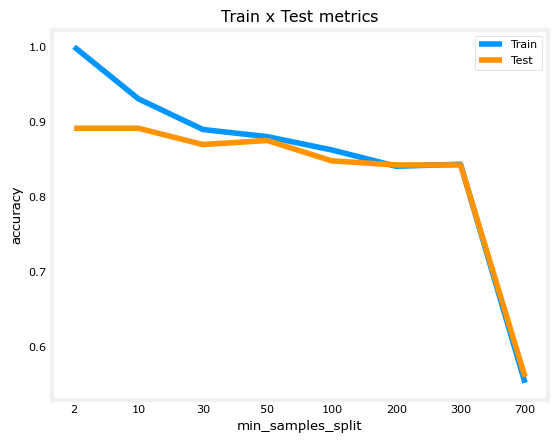

In [21]:
accuracy_list_train = []
accuracy_list_test = []
for min_samples_split in min_samples_split_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(min_samples_split = min_samples_split,
                                   random_state = RANDOM_STATE).fit(X_train,y_train)
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

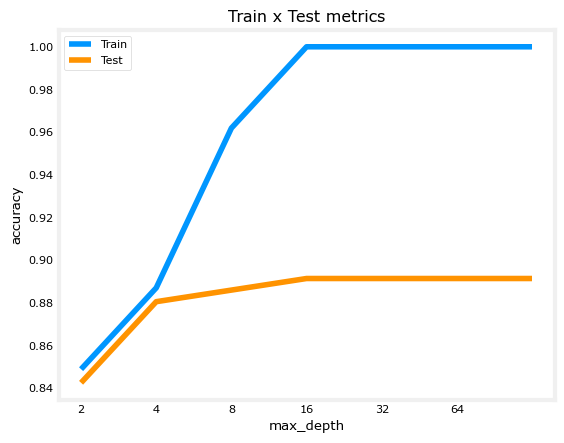

In [22]:
accuracy_list_train = []
accuracy_list_test = []
for max_depth in max_depth_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(max_depth = max_depth,
                                   random_state = RANDOM_STATE).fit(X_train,y_train)
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

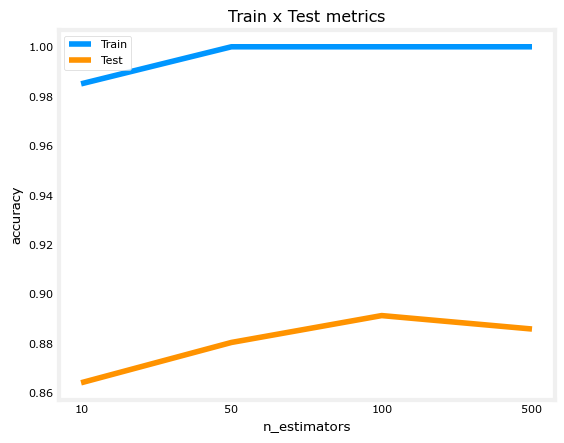

In [23]:
accuracy_list_train = []
accuracy_list_test = []
for n_estimators in n_estimators_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(n_estimators = n_estimators,
                                   random_state = RANDOM_STATE).fit(X_train,y_train)
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(n_estimators_list )),labels=n_estimators_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

Let's then fit a random forest with the following parameters:

 - max_depth: 8
 - min_samples_split: 10
 - n_estimators: 100

In [24]:
random_forest_model = RandomForestClassifier(n_estimators = 100,
                                             max_depth = 8,
                                             min_samples_split = 10, random_state = RANDOM_STATE).fit(X_train,y_train)

In [25]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(X_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(X_test),y_test):.4f}")

Metrics train:
	Accuracy score: 0.9183
Metrics test:
	Accuracy score: 0.8804


You have demonstrated how to look for the best value hyperparameter-by-hyperparameter. However, you should not overlook that as we experiment with one hyperparameter we always have to fix the others at some default values. This makes us only able to tell how the hyperparameter value changes with respect to those defaults. In princple, if you have 4 values to try out in each of the 3 hyperparameters being tuned, you should have a total of 4 x 4 x 4 = 64 combinations, however, the way you are doing will only give us 4 + 4 + 4 = 12 results. To try out all combinations, you can use a sklearn implementation called GridSearchCV, moreover, it has a refit parameter that will automatically refit a model on the best combination so you will not need to program it explicitly. For more on GridSearchCV, please refer to its [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

## ✅ Activity: Feature Importance analysis with Random Forests

1. Extract feature importance scores from the random_forest_model.

2. Visualize the top 10 most important features using a bar plot.

3. Discuss your observations about the relative importance of different features in predicting heart disease.

Top 10 most important features:


,feature,importance
19,ST_Slope_Up,0.186100
18,ST_Slope_Flat,0.141879
8,ChestPainType_ASY,0.094955
5,Oldpeak,0.094163
16,ExerciseAngina_Y,0.069394
2,Cholesterol,0.069241
15,ExerciseAngina_N,0.065343
4,MaxHR,0.061523
0,Age,0.047588
1,RestingBP,0.039193


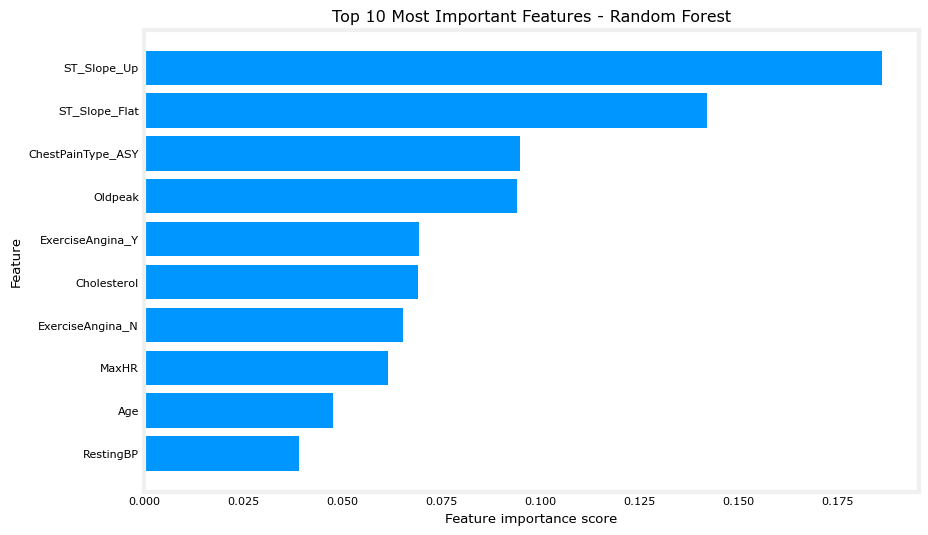

In [26]:
# Feature Importance analysis with Random Forests

# 1) Extract feature importance scores
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': random_forest_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Top 10 most important features:")
display(feature_importance.head(10))

# 2) Visualize the top 10 features
top_10_features = feature_importance.head(10).sort_values(by='importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_10_features['feature'], top_10_features['importance'])
plt.title('Top 10 Most Important Features - Random Forest')
plt.xlabel('Feature importance score')
plt.ylabel('Feature')
plt.show()

De acuerdo con el modelo, las variables más importantes para predecir la enfermedad cardíaca son ST_Slope_Up (0.1861) y ST_Slope_Flat (0.1419), lo que indica que la pendiente del segmento ST en el electrocardiograma es uno de los factores más influyentes en la clasificación. Esto es consistente con el conocimiento médico, ya que las alteraciones del segmento ST suelen estar relacionadas con problemas cardíacos.

Otras variables con alta importancia son ChestPainType_ASY (0.0950) y Oldpeak (0.0942). El tipo de dolor de pecho asintomático (ASY) y la depresión del segmento ST inducida por el ejercicio (Oldpeak) también aportan información relevante para identificar pacientes con enfermedad cardíaca.

Variables como ExerciseAngina_Y, Cholesterol, MaxHR y Age presentan una importancia intermedia, lo que sugiere que contribuyen al modelo, aunque en menor medida que las anteriores.

Finalmente, RestingBP aparece entre las variables menos importantes del conjunto mostrado, indicando que, para este modelo y este conjunto de datos, su influencia en la predicción es relativamente baja.

En general, el modelo otorga mayor relevancia a las variables relacionadas con los resultados del electrocardiograma y la respuesta al ejercicio que a variables demográficas o signos clínicos básicos, lo que sugiere que estas características contienen mayor información para discriminar entre pacientes con y sin enfermedad cardíaca.

## 4.3 XGBoost

Now, the last model you will test in this lab is the Gradient Boosting model, called XGBoost. As you've seen in the lectures, the boosting methods train several trees, but instead of them being uncorrelated to each other, now the trees are fitted subsequently to minimize the error.

The parameters that this model comprises is the same as the parameters for any decision tree, plus some others, such as the learning rate, which is the size of the step on the Gradient Descent method that the XGBoost uses internally to minimize the error on each train step.

One interesting thing about the XGBoost is that it allows, during the fit, to pass a list evaluation datasets of the form `(X_val,y_val)`, where on each iteration, it measures the cost (or evaluation metric) on the evaluation datasets so that once the cost (or metric) stops to descrease for a number of rounds (called early_stopping_rounds), the training will stop. This is how we can automatically control how many estimators is enough, and how we can avoid overfitting due to too many estimators.

First, let's define a subset of our training set (we should not use the test set here).

In [27]:
n = int(len(X_train)*0.8) ## Let's use 80% to train and 20% to eval

In [28]:
X_train_fit, X_train_eval, y_train_fit, y_train_eval = X_train[:n], X_train[n:], y_train[:n], y_train[n:]

You can then set a large number of estimators, because you can stop if the cost function stops decreasing.

In [29]:
xgb_model = XGBClassifier(n_estimators = 500, learning_rate = 0.1,verbosity = 1, random_state = RANDOM_STATE, early_stopping_rounds=50)
xgb_model.fit(X_train_fit,y_train_fit, eval_set = [(X_train_eval,y_train_eval)])
# Here we must pass a list to the eval_set, because you can have several different tuples ov eval sets. The parameter
# early_stopping_rounds is the number of iterations that it will wait to check if the cost function decreased or not.
# If not, it will stop and get the iteration that returned the lowest metric on the eval set.

[0]	validation_0-logloss:0.63301
[1]	validation_0-logloss:0.59553
[2]	validation_0-logloss:0.56612
[3]	validation_0-logloss:0.54186
[4]	validation_0-logloss:0.52348
[5]	validation_0-logloss:0.50610
[6]	validation_0-logloss:0.49371
[7]	validation_0-logloss:0.48365
[8]	validation_0-logloss:0.47321
[9]	validation_0-logloss:0.46537
[10]	validation_0-logloss:0.45999
[11]	validation_0-logloss:0.45620
[12]	validation_0-logloss:0.45482
[13]	validation_0-logloss:0.44974
[14]	validation_0-logloss:0.44494
[15]	validation_0-logloss:0.44072
[16]	validation_0-logloss:0.44078
[17]	validation_0-logloss:0.43935
[18]	validation_0-logloss:0.44206
[19]	validation_0-logloss:0.44536
[20]	validation_0-logloss:0.44321
[21]	validation_0-logloss:0.44310
[22]	validation_0-logloss:0.44419
[23]	validation_0-logloss:0.44797
[24]	validation_0-logloss:0.44843
[25]	validation_0-logloss:0.45337
[26]	validation_0-logloss:0.45206
[27]	validation_0-logloss:0.45435
[28]	validation_0-logloss:0.45316
[29]	validation_0-loglos

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


As you can see, even though you passed 500 estimators to fit, the algorithm only fitted 66 because the log-loss used to metrify the training rounds started to increase. In fact, the number of estimators is even less than 66. If you take a closeer look to the metrics, you see that with 16 fitted trees, we achieved the minimum value of the log-loss, and in fact, this is the number of fitted trees in the final model:

In [30]:
xgb_model.best_iteration

17

In [31]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(xgb_model.predict(X_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(xgb_model.predict(X_test),y_test):.4f}")

Metrics train:
	Accuracy score: 0.9319
Metrics test:
	Accuracy score: 0.8533


You can see that RandomForest achieved the best accuracy, but the results overall were close. And note that we got a very close test metric with XGBoost compared to RandomForest, and we didn't even performed any hyperparameter search! The advantage of XGBoost is that it is faster than the Random Forest and also it has more parameters, therefore you are able to fine-tune the model to achieve even better results.


Congratulations, you have learned how to use Decision Tree, Random Forest from the scikit-learn library and XGBoost!

## ✅ Optimizing XGBoost for Heart Disease Prediction

Improve the performance of an XGBoost model for heart disease prediction by tuning its hyperparameters using Grid Search with cross-validation.

In [32]:
# Optimizing XGBoost for Heart Disease Prediction using GridSearchCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

best_xgb_model = grid_xgb.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test)

print("Best XGBoost parameters:")
print(grid_xgb.best_params_)
print(f"Best CV accuracy: {grid_xgb.best_score_:.4f}")
print(f"Train accuracy: {accuracy_score(y_train, best_xgb_model.predict(X_train)):.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_xgb))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best XGBoost parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV accuracy: 0.8733
Train accuracy: 0.9401
Test accuracy: 0.8913

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        81
           1       0.92      0.88      0.90       103

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

Confusion matrix:
[[73  8]
 [12 91]]


Estos parámetros indican que el modelo utiliza árboles relativamente poco profundos y una tasa de aprendizaje baja, compensada con un mayor número de árboles. Además, el uso de subsample y colsample_bytree ayuda a reducir el sobreajuste y mejora la capacidad de generalización.

La mejor exactitud obtenida mediante validación cruzada fue de 87.33%, mientras que la exactitud sobre el conjunto de prueba alcanzó 89.13%. Por otro lado, la exactitud en entrenamiento fue de 94.01%, ligeramente superior a la de prueba, lo que sugiere un leve sobreajuste, aunque la diferencia no es excesiva y el modelo generaliza adecuadamente.

El reporte de clasificación muestra un desempeño equilibrado entre ambas clases. Para la clase 0, el modelo obtuvo una precisión de 0.86, un recall de 0.90 y un F1-score de 0.88. Para la clase 1, la precisión fue de 0.92, el recall de 0.88 y el F1-score de 0.90. El F1-score macro de 0.89 indica que el modelo mantiene un rendimiento similar en ambas clases.

La matriz de confusión muestra que:

73 pacientes sanos fueron clasificados correctamente.
91 pacientes con enfermedad cardíaca fueron clasificados correctamente.
8 pacientes sanos fueron clasificados erróneamente como enfermos (falsos positivos).
12 pacientes con enfermedad cardíaca fueron clasificados erróneamente como sanos (falsos negativos).

En general, XGBoost presenta un muy buen desempeño, con una exactitud cercana al 90% y un balance adecuado entre precisión y recall. Aunque existen algunos falsos negativos, el modelo demuestra una buena capacidad para identificar correctamente a los pacientes con enfermedad cardíaca y constituye una alternativa robusta para este problema de clasificación.

# ✅ Building a Stacked Ensemble for Heart Disease Prediction

 Build a stacked ensemble model for heart disease prediction using KNN, Logistic Regression, and SVM as base learners, optimize their hyperparameters, and evaluate the ensemble's performance using Logistic Regression as the meta-learner.

 🧠 **Note on SVM (Support Vector Machine)**

Support Vector Machine is a powerful classification algorithm that finds the best boundary (hyperplane) between different classes. However, it might seem complex at first. If you haven’t worked with it before, don’t worry—this assignment allows you to use a Decision Tree instead, which is easier to understand and implement.


In [33]:
# Building a Stacked Ensemble for Heart Disease Prediction
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier

# KNN, Logistic Regression and SVM need scaling, so each model is placed inside a Pipeline.
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE))
])

# Hyperparameter optimization for each base learner
param_grid_knn = {'knn__n_neighbors': [3, 5, 7, 9, 11], 'knn__weights': ['uniform', 'distance']}
param_grid_logreg = {'logreg__C': [0.01, 0.1, 1, 10], 'logreg__solver': ['lbfgs', 'liblinear']}
param_grid_svm = {'svm__C': [0.1, 1, 10], 'svm__gamma': ['scale', 0.01, 0.1], 'svm__kernel': ['rbf']}

best_knn = GridSearchCV(knn_pipe, param_grid_knn, cv=cv, scoring='accuracy', n_jobs=-1).fit(X_train, y_train).best_estimator_
best_logreg = GridSearchCV(logreg_pipe, param_grid_logreg, cv=cv, scoring='accuracy', n_jobs=-1).fit(X_train, y_train).best_estimator_
best_svm = GridSearchCV(svm_pipe, param_grid_svm, cv=cv, scoring='accuracy', n_jobs=-1).fit(X_train, y_train).best_estimator_

stacked_model = StackingClassifier(
    estimators=[
        ('knn', best_knn),
        ('logreg', best_logreg),
        ('svm', best_svm)
    ],
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    cv=cv,
    n_jobs=-1,
    passthrough=False
)

stacked_model.fit(X_train, y_train)
y_pred_stack = stacked_model.predict(X_test)

print(f"Optimized KNN test accuracy: {accuracy_score(y_test, best_knn.predict(X_test)):.4f}")
print(f"Optimized Logistic Regression test accuracy: {accuracy_score(y_test, best_logreg.predict(X_test)):.4f}")
print(f"Optimized SVM test accuracy: {accuracy_score(y_test, best_svm.predict(X_test)):.4f}")
print(f"Stacked ensemble test accuracy: {accuracy_score(y_test, y_pred_stack):.4f}")
print("\nClassification report - Stacked Ensemble:")
print(classification_report(y_test, y_pred_stack))

Optimized KNN test accuracy: 0.8424
Optimized Logistic Regression test accuracy: 0.8696
Optimized SVM test accuracy: 0.8967
Stacked ensemble test accuracy: 0.8804

Classification report - Stacked Ensemble:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        81
           1       0.89      0.89      0.89       103

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



Se evaluaron tres modelos base optimizados: K-Nearest Neighbors (KNN), Regresión Logística y Support Vector Machine (SVM). Sus exactitudes en el conjunto de prueba fueron:

KNN: 84.24%
Regresión Logística: 86.96%
SVM: 89.67%
Stacked Ensemble: 88.04%

El modelo SVM obtuvo el mejor desempeño individual, alcanzando una exactitud del 89.67%. Por su parte, el Stacked Ensemble logró una exactitud de 88.04%, superior a KNN y Regresión Logística, pero ligeramente inferior a la obtenida por SVM.

El reporte de clasificación muestra un desempeño equilibrado entre ambas clases. Para la clase 0, el modelo obtuvo una precisión, recall y F1-score de 0.86. Para la clase 1, estos valores fueron 0.89, lo que indica que el modelo clasifica ambas clases de forma consistente, sin favorecer significativamente a una sobre la otra. Además, el F1-score macro de 0.88 confirma un rendimiento balanceado.

En este caso, el uso de un Stacked Ensemble no produjo una mejora respecto al mejor modelo individual (SVM). Esto puede ocurrir cuando uno de los modelos base ya captura adecuadamente los patrones del conjunto de datos y los demás modelos aportan información similar, limitando el beneficio de combinarlos.

En conclusión, aunque el Stacked Ensemble ofrece un rendimiento sólido y estable, SVM continúa siendo la mejor alternativa para este conjunto de datos, al obtener la mayor exactitud en el conjunto de prueba.

# ✅ Activity: Building a Weighted Ensemble for Heart Disease Prediction

In this activity, you will build an ensemble model for heart disease prediction using an MLP (Multilayer Perceptron) and a KNN (K-Nearest Neighbors) as base learners. You will optimize both base learners using Grid Search and then combine their predictions using a weighted average,  with 0.75 weight for the MLP and 0.25 weight for the KNN.

What is the role of the weights in the weighted average prediction?

Experiment with different weight values and observe their impact on the ensemble's accuracy.

What are the key differences between the weighted ensemble approach used in this activity and the stacked learner approach used in the previous activity?



In [34]:
# Building a Weighted Ensemble with MLP and KNN
from sklearn.neural_network import MLPClassifier

mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=2000, random_state=RANDOM_STATE, early_stopping=True))
])

knn_pipe_weighted = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(32,), (64,), (32, 16)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001, 0.01]
}

param_grid_knn_weighted = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance']
}

best_mlp = GridSearchCV(mlp_pipe, param_grid_mlp, cv=cv, scoring='accuracy', n_jobs=-1).fit(X_train, y_train).best_estimator_
best_knn_weighted = GridSearchCV(knn_pipe_weighted, param_grid_knn_weighted, cv=cv, scoring='accuracy', n_jobs=-1).fit(X_train, y_train).best_estimator_

# Probabilities for class 1
mlp_proba = best_mlp.predict_proba(X_test)[:, 1]
knn_proba = best_knn_weighted.predict_proba(X_test)[:, 1]

# Required weighted average: 0.75 MLP + 0.25 KNN
weighted_proba = 0.75 * mlp_proba + 0.25 * knn_proba
weighted_pred = (weighted_proba >= 0.5).astype(int)

print(f"Optimized MLP test accuracy: {accuracy_score(y_test, best_mlp.predict(X_test)):.4f}")
print(f"Optimized KNN test accuracy: {accuracy_score(y_test, best_knn_weighted.predict(X_test)):.4f}")
print(f"Weighted Ensemble 0.75 MLP / 0.25 KNN accuracy: {accuracy_score(y_test, weighted_pred):.4f}")

# Experiment with different weights
results_weights = []
for w_mlp in np.arange(0, 1.01, 0.10):
    w_knn = 1 - w_mlp
    proba = w_mlp * mlp_proba + w_knn * knn_proba
    pred = (proba >= 0.5).astype(int)
    results_weights.append({
        'weight_mlp': round(w_mlp, 2),
        'weight_knn': round(w_knn, 2),
        'accuracy': accuracy_score(y_test, pred)
    })

results_weights_df = pd.DataFrame(results_weights)
display(results_weights_df)


Optimized MLP test accuracy: 0.8533
Optimized KNN test accuracy: 0.8424
Weighted Ensemble 0.75 MLP / 0.25 KNN accuracy: 0.8641


,weight_mlp,weight_knn,accuracy
0,0.0,1.0,0.842391
1,0.1,0.9,0.842391
2,0.2,0.8,0.842391
3,0.3,0.7,0.847826
4,0.4,0.6,0.858696
5,0.5,0.5,0.864130
6,0.6,0.4,0.869565
7,0.7,0.3,0.858696
8,0.8,0.2,0.864130
9,0.9,0.1,0.864130


Al probar diferentes combinaciones de pesos entre MLP y KNN, se observa que el rendimiento del ensemble varía dependiendo de la importancia asignada a cada modelo. El mejor resultado se obtuvo con 60% de peso para MLP y 40% para KNN, alcanzando una exactitud de 86.96%. También se obtuvieron buenos resultados con pesos de 50%-50%, 80%-20% y 90%-10%, con una exactitud cercana al 86.41%.

En cambio, cuando se asigna todo el peso a un solo modelo, la precisión disminuye: el MLP alcanza una exactitud de 85.33%, mientras que el KNN obtiene 84.24%. Esto demuestra que combinar las predicciones de ambos modelos permite aprovechar las fortalezas de cada uno y mejorar ligeramente el rendimiento respecto a utilizarlos por separado.

El Weighted Ensemble combina las predicciones de varios modelos utilizando pesos predefinidos. Cada modelo contribuye a la decisión final según la importancia que se le asigne, por lo que el rendimiento depende de elegir adecuadamente esos pesos. Es un método sencillo, fácil de implementar y de interpretar.

Por otro lado, el Stacked Learner (Stacking) utiliza un meta-modelo que aprende automáticamente cómo combinar las predicciones de los modelos base. En lugar de asignar pesos manualmente, el meta-modelo identifica qué modelo es más confiable en distintas situaciones y toma la decisión final en función de ese aprendizaje.

En este ejercicio, el Weighted Ensemble obtuvo una exactitud máxima de 86.96%, mientras que el Stacked Ensemble alcanzó 88.04%. Esto indica que el enfoque de Stacking logró combinar la información de los modelos de manera más efectiva, obteniendo un mejor desempeño que el promedio ponderado de las predicciones.

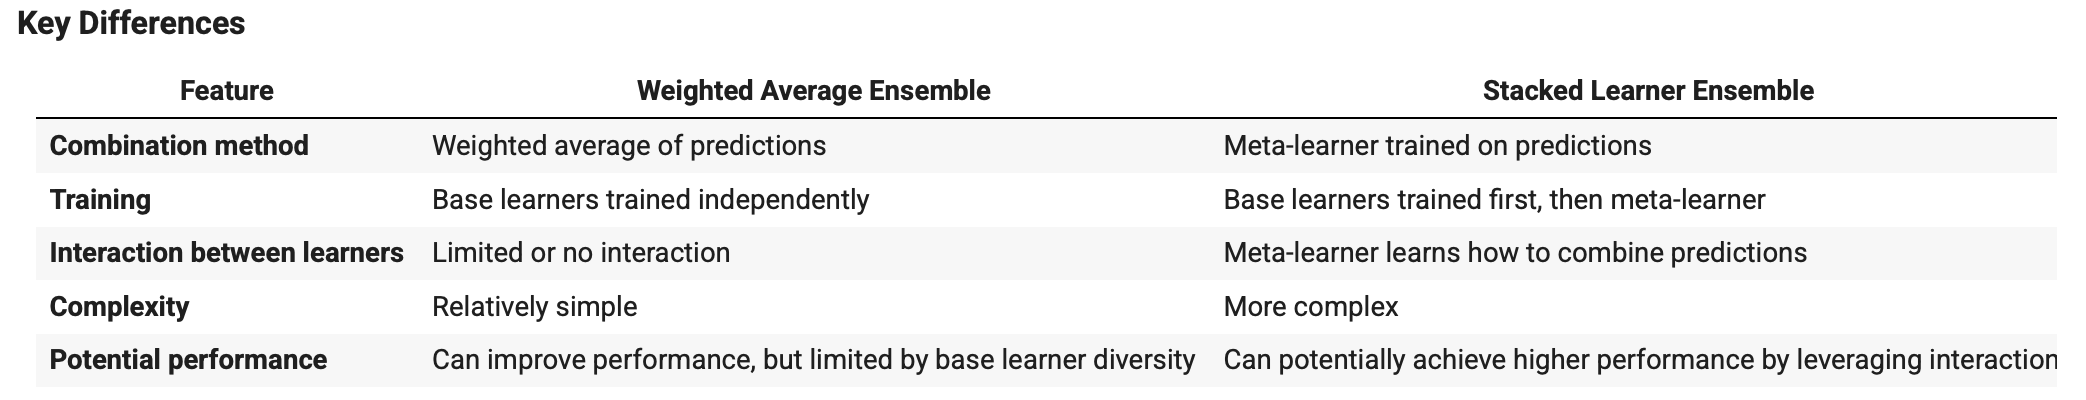

# ✅ Building and Comparing Voting Strategies in Ensemble Models



Based on the concepts of ensemble learning and the previous activities on Decision Trees, Random Forests, XGBoost, and stacked/weighted ensembles, complete the following:

1.  **Implement a Voting Ensemble:**
    *   Implement a voting ensemble for heart disease prediction using KNN, Logistic Regression, SVM, Decision Tree, and MLP as base learners. Check the class `VotingClassifier`. 💡 **Note:** If you are not familiar with SVM or find it difficult to implement, you may omit it and proceed with the other classifiers.
    *   Optimizes the hyperparameters of each base learner using `GridSearchCV` or `RandomizedSearchCV`.
    *   Use both the "hard voting" and "soft voting" ensembles.

2.  **Compare Hard vs. Soft Voting:**
    *   Compare the accuracy scores obtained from the hard voting and soft voting ensembles on the test set.
    *   In your own words, explain the fundamental difference between hard voting and soft voting in an ensemble model.
    *   Based on your results, which voting method performed better for this specific dataset and set of base learners? Can you hypothesize why this might be the case?

3.  **Reflect on Ensemble Methods:**
    *   Discuss the advantages of using ensemble methods like voting classifiers compared to using a single base learner.
    *   Consider the previous activities on stacked and weighted ensembles. How do these approaches differ from the voting ensemble implemented in this homework? What are potential benefits or drawbacks of each approach?


In [35]:
# Building and Comparing Voting Strategies in Ensemble Models
from sklearn.ensemble import VotingClassifier

# Additional base learner: Decision Tree
param_grid_dt = {
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 10, 30, 50]
}

best_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
).fit(X_train, y_train).best_estimator_

# We reuse the optimized KNN, Logistic Regression, SVM and MLP if they were already created.
# If this cell is run independently, the previous activity cells should be executed first.
base_estimators = [
    ('knn', best_knn_weighted),
    ('logreg', best_logreg),
    ('svm', best_svm),
    ('dt', best_dt),
    ('mlp', best_mlp)
]

hard_voting_model = VotingClassifier(
    estimators=base_estimators,
    voting='hard',
    n_jobs=-1
)

soft_voting_model = VotingClassifier(
    estimators=base_estimators,
    voting='soft',
    n_jobs=-1
)

hard_voting_model.fit(X_train, y_train)
soft_voting_model.fit(X_train, y_train)

hard_pred = hard_voting_model.predict(X_test)
soft_pred = soft_voting_model.predict(X_test)

hard_accuracy = accuracy_score(y_test, hard_pred)
soft_accuracy = accuracy_score(y_test, soft_pred)

print(f"Hard Voting accuracy: {hard_accuracy:.4f}")
print(f"Soft Voting accuracy: {soft_accuracy:.4f}")

comparison_voting = pd.DataFrame({
    'model': ['Hard Voting', 'Soft Voting'],
    'accuracy': [hard_accuracy, soft_accuracy]
})
display(comparison_voting)

Hard Voting accuracy: 0.8750
Soft Voting accuracy: 0.8750


,model,accuracy
0,Hard Voting,0.875
1,Soft Voting,0.875


#### Comparación de la exactitud

Tanto el Hard Voting como el Soft Voting obtuvieron una exactitud de 87.50% en el conjunto de prueba. Esto indica que, para este conjunto de datos y los modelos base utilizados, ambos métodos ofrecieron exactamente el mismo desempeño.

Diferencia fundamental entre Hard Voting y Soft Voting

La principal diferencia radica en la forma en que combinan las predicciones de los modelos:

Hard Voting: cada clasificador emite un voto por una clase y la predicción final corresponde a la clase con mayor número de votos. No considera el nivel de confianza de cada modelo.
Soft Voting: utiliza las probabilidades estimadas por cada clasificador para cada clase y calcula un promedio de dichas probabilidades. La clase con la mayor probabilidad promedio es la seleccionada como predicción final.

En este ejercicio ninguno de los dos métodos superó al otro, ya que ambos alcanzaron una exactitud de 87.50%. Esto puede deberse a que los modelos base generaron predicciones y probabilidades muy similares, por lo que considerar las probabilidades (Soft Voting) no aportó una ventaja adicional respecto a la votación por mayoría (Hard Voting). Además, el conjunto de datos es relativamente pequeño, por lo que las diferencias entre ambos enfoques pueden ser mínimas.

#### Reflexión sobre los métodos Ensemble

Ventajas de utilizar métodos Ensemble

Los métodos Ensemble combinan las predicciones de varios modelos para obtener un resultado más robusto y estable. Entre sus principales ventajas se encuentran:

Reducen la varianza y el riesgo de sobreajuste.
Mejoran la capacidad de generalización.
Aprovechan las fortalezas de diferentes algoritmos.
Suelen ofrecer un rendimiento más estable que un único modelo.
Diferencias entre Voting, Weighted Ensemble y Stacked Ensemble

Los tres enfoques combinan varios modelos, pero lo hacen de manera distinta:

Voting Ensemble: combina las predicciones mediante una votación simple (Hard Voting) o utilizando el promedio de probabilidades (Soft Voting). Es el método más sencillo y no requiere entrenar un modelo adicional.
Weighted Ensemble: también combina las predicciones, pero asigna diferentes pesos a cada modelo según su importancia o desempeño. De esta manera, algunos modelos tienen mayor influencia en la decisión final.
Stacked Ensemble (Stacking): utiliza un meta-modelo que aprende automáticamente cómo combinar las predicciones de los modelos base. En lugar de usar reglas fijas, aprende la mejor forma de integrarlas.
Beneficios y desventajas de cada enfoque
Voting Ensemble: es simple, rápido y fácil de implementar, aunque no aprende cuál modelo es mejor en diferentes situaciones.
Weighted Ensemble: permite dar mayor importancia a los modelos con mejor desempeño, pero requiere encontrar una combinación adecuada de pesos.
Stacked Ensemble: suele obtener el mejor rendimiento porque aprende automáticamente a combinar los modelos; sin embargo, es más complejo, requiere entrenar un meta-modelo y tiene un mayor costo computacional.

En este ejercicio, el Voting Ensemble obtuvo una exactitud de 87.50%, mientras que en la actividad anterior el Stacked Ensemble alcanzó 88.04%, mostrando un rendimiento ligeramente superior gracias a que el meta-modelo puede aprender una combinación más eficiente de las predicciones de los modelos base.

# ✅ Auto Machine Learning (AutoML) using AutoGluon

**What is AutoML?**

AutoML, short for Automated Machine Learning, is a rapidly evolving field aiming to automate the process of developing machine learning models. Traditionally, building a model involves manual steps like data preprocessing, feature engineering, model selection, hyperparameter tuning, and evaluation, requiring significant expertise and time.
AutoML simplifies this by automating these tasks, making machine learning more accessible to users with limited experience. AutoML tools use advanced algorithms and techniques to automatically explore different model architectures and hyperparameter settings, finding the best model for a given dataset and task.

**Benefits of AutoML:**

**Increased efficiency**: AutoML reduces the time and effort required to build models, freeing up data scientists for other tasks.

**Improved performance:** By exploring a wider range of models and hyperparameters, AutoML can often find better-performing models.

**Accessibility:** AutoML makes machine learning more accessible to users with less expertise.

**Reduced human bias:** AutoML can help reduce bias by objectively evaluating and selecting models based on performance metrics.

**Criticisms of AutoML:**

Despite its advantages, AutoML also faces some criticisms:

**Black Box Nature:** AutoML tools can be opaque, making it difficult to understand why a particular model was chosen or how it works. This lack of transparency can be a concern, especially in sensitive applications.

**Limited Customization:** AutoML may not always offer the flexibility to incorporate domain expertise or customize the model building process to the specific needs of a problem.

**Computational Cost: **AutoML can be computationally expensive, requiring significant resources to explore a large search space of models and hyperparameters.

**Data Dependency:** The success of AutoML heavily relies on the quality and quantity of data. If the data is noisy, incomplete, or biased, AutoML may not produce reliable results.

**Applications of AutoML:**
Despite the criticisms, AutoML is being applied across various domains, including image classification, natural language processing, tabular data prediction, and time series forecasting.

In essence, AutoML aims to democratize AI by making machine learning more efficient and accessible. However, it's important to be aware of its limitations and use it judiciously, combining its power with human expertise for optimal results.

**Activity:**

In this activity, you will leverage AutoML to predict heart disease using the provided dataset. Explore the AutoML library AutoGluon to automate the model building process, including data preprocessing, model selection, and hyperparameter tuning. Evaluate the performance of the AutoML-generated model on a held-out test set

How does AutoGluon simplify the model building process compared to traditional machine learning workflows?

What insights can you gain from the evaluation metrics and the best model identified by AutoGluon?

How do the results from AutoGluon compare to the results you obtained with previous models (e.g., the weighted ensemble)?


In [36]:
!pip install autogluon.tabular --quiet

In [37]:
# AutoML using AutoGluon
# Note: AutoGluon may take several minutes to install/run depending on the environment.
from autogluon.tabular import TabularPredictor

# AutoGluon works directly with a DataFrame containing the target column.
train_data_ag = X_train.copy()
train_data_ag['HeartDisease'] = y_train.values

test_data_ag = X_test.copy()
test_data_ag['HeartDisease'] = y_test.values

predictor = TabularPredictor(
    label='HeartDisease',
    eval_metric='accuracy',
    path='AutogluonModels_heart'
).fit(
    train_data=train_data_ag,
    presets='medium_quality',
    time_limit=120
)

leaderboard = predictor.leaderboard(test_data_ag, silent=True)
display(leaderboard)

y_pred_ag = predictor.predict(test_data_ag.drop(columns=['HeartDisease']))
print(f"AutoGluon test accuracy: {accuracy_score(y_test, y_pred_ag):.4f}")

# Feature importance calculated by AutoGluon
feature_importance = predictor.feature_importance(test_data_ag)
display(feature_importance)

Verbosity: 2 (Standard Logging)
c:\ProgramData\anaconda3\envs\telemedicina_gpu\lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.10.19
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19041
CPU Count:          12
Pytorch Version:    2.5.1
CUDA Version:       11.8
GPU Memory:         GPU 0: 4.00/4.00 GB
Total GPU Memory:   Free: 4.00 GB, Allocated: 0.00 GB, Total: 4.00 GB
GPU Count:          1
Memory Avail:       4.59 GB / 15.86 GB (28.9%)
Disk Space Avail:   3.73 GB / 222.98 GB (1.7%)
	We recommend a minimum available disk space of 10 GB, and large datasets may require more.
Presets specified: ['medium_quality']
Using

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetTorch,0.885870,0.877551,accuracy,0.061000,0.018998,9.461309,0.061000,0.018998,9.461309,1,True,6
1,ExtraTreesGini,0.885870,0.863946,accuracy,0.126589,0.125986,1.475141,0.126589,0.125986,1.475141,1,True,3
2,RandomForestGini,0.885870,0.877551,accuracy,0.126960,0.157998,1.408000,0.126960,0.157998,1.408000,1,True,1
3,WeightedEnsemble_L2,0.885870,0.891156,accuracy,0.229423,0.180038,11.149385,0.042002,0.002037,0.082072,2,True,7
4,XGBoost,0.885870,0.870748,accuracy,0.311681,0.014005,1.171960,0.311681,0.014005,1.171960,1,True,5
5,ExtraTreesEntr,0.880435,0.877551,accuracy,0.109994,0.108289,1.295915,0.109994,0.108289,1.295915,1,True,4
6,RandomForestEntr,0.875000,0.884354,accuracy,0.126421,0.159004,1.606004,0.126421,0.159004,1.606004,1,True,2


Computing feature importance via permutation shuffling for 20 features using 184 rows with 5 shuffle sets...
	20.79s	= Expected runtime (4.16s per shuffle set)


AutoGluon test accuracy: 0.8859


	2.13s	= Actual runtime (Completed 5 of 5 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
ST_Slope_Flat,0.035870,0.017014,0.004605,5,0.070901,0.000838
ST_Slope_Up,0.033696,0.012393,0.001850,5,0.059213,0.008178
Oldpeak,0.020652,0.012975,0.011803,5,0.047369,-0.006064
FastingBS,0.007609,0.004861,0.012448,5,0.017618,-0.002400
Sex_F,0.005435,0.008593,0.115100,5,0.023128,-0.012259
Cholesterol,0.005435,0.006656,0.070964,5,0.019140,-0.008270
Age,0.005435,0.006656,0.070964,5,0.019140,-0.008270
RestingBP,0.005435,0.000000,0.500000,5,0.005435,0.005435
MaxHR,0.005435,0.013856,0.214987,5,0.033965,-0.023095
ChestPainType_ASY,0.003261,0.002977,0.035242,5,0.009390,-0.002868


In [ ]:
print(feature_importance)

# ✅ Exploring TabPFN for Heart Disease Prediction

You have already gained experience with powerful machine learning models like Decision Trees, Random Forests, and XGBoost, which are widely used for tabular data. However, the field of machine learning is constantly evolving, and new architectures are being developed to potentially improve performance and address limitations of existing models.

One such model is TabPFN (Tabular Feature Processing Network). Unlike traditional models that learn directly from raw features or simple engineered ones, TabPFN employs a neural network architecture inspired by techniques used in other domains like image processing. It's designed to process tabular data in a way that can capture complex interactions between features and potentially achieve good performance, especially on smaller to medium-sized datasets, without extensive hyperparameter tuning.
TabPFN's importance lies in its potential to:

* Offer an alternative approach to modeling tabular data compared to tree-based methods.
* Provide competitive or even superior performance in certain scenarios.
* Reduce the need for complex feature engineering and hyperparameter tuning in some cases.

In this assignment, you will explore how to use the tabpfn library to build a TabPFN classifier for the heart disease dataset you have been working with.

**Instructions:**

1. Install the tabpfn library in your Colab notebook using pip. Please read the repo https://github.com/PriorLabs/TabPFN
2. Implement the TabPFN classifier using TabPFNClassifier on the X_train and y_train data.
3. Predict class labels and probabilities on the X_test data.
4. Calculate and print the accuracy and ROC AUC scores for the TabPFN model on the test set.

**Reflective Questions:**

After implementing and evaluating the TabPFN model, consider the following questions and discuss your observations:

1. **Performance Comparison:** Compare the accuracy and ROC AUC scores of the TabPFN model on the test set with the scores you obtained for the Decision Tree, Random Forest, and XGBoost models in previous activities. Which model performed best on this dataset? Are the differences significant?

2. **Ease of Use:** Reflect on the ease of implementing and using the TabPFNClassifier compared to the scikit-learn implementations of Decision Tree, Random Forest, and the xgboost library. Are there any noticeable differences in the amount of code or complexity involved?

3. **Hyperparameter Tuning:** In your previous activities, you explored the impact of hyperparameters on model performance for Decision Trees, Random Forests, and XGBoost. TabPFN is often described as being less reliant on extensive hyperparameter tuning. Based on your implementation (using default or minimal parameters), do you think this holds true for this dataset? Why or why not?

4. **Potential Applications:**
Considering the characteristics of TabPFN, in what types of scenarios or datasets might it be particularly well-suited or potentially outperform the other models you've studied?

5. **Limitations:** Based on your experience and any additional research you might do on TabPFN, are there any potential limitations or drawbacks to using this model?



In [ ]:
# your code here

# ✅ Activity: Building a Bagging Ensemble with Optimized SVMs.

In this activity, you will build a Bagging ensemble with optimized SVMs (RBF kernel) as base learners, specifically using 20 of these base learners. Use BaggingClassifier Class.  Compare the accuracy of this Bagging model (with 20 estimators) to the optimized individual SVM and the previous ensemble models.

🧩 **Alternative Option:** If you are not familiar with SVMs or face implementation difficulties, you may use Decision Trees or KNN instead as base learners in the Bagging ensemble.

In [ ]:
#your code here